# Análisis costo-beneficio y comparación con aprendizaje no supervisado

Este notebook responde dos preguntas que las métricas de clasificación no resuelven por sí solas:

1. **¿El modelo genera valor?** Se cuantifica el costo de actuar sobre un falso positivo y el de no
   detectar un abandono, se construye una función de beneficio neto y se determina el umbral
   económicamente óptimo para distintos escenarios de intervención. Después se verifica si esa
   ventaja se sostiene sobre el conjunto de prueba.
2. **¿Por qué se mantiene el enfoque supervisado?** Se aplica K-means sobre las mismas
   características preprocesadas y se compara, con evidencia experimental, qué aporta la
   segmentación frente al modelo supervisado.

El notebook **no reentrena ni modifica** el modelo final: carga los artefactos congelados en
`06_refinamiento_modelo.ipynb` y evaluados en `08_evaluacion_final_test.ipynb`. El conjunto de
prueba se usa únicamente para **verificar** si el umbral elegido en validación generaliza; ninguna
decisión de este notebook se toma mirando prueba.

Salidas que genera:

- `models/analisis_costo_beneficio.csv` — beneficio neto por escenario y umbral.
- `models/sensibilidad_precision_equilibrio.csv` — precisión de equilibrio según costo y efectividad.
- `models/perfil_clusters_kmeans.csv` — perfil de los clústeres con k = 6.
- `figures/14_01_beneficio_neto_umbral.png` — curva de beneficio neto.
- `figures/14_02_tasa_churn_por_cluster.png` — tasa de abandono por clúster.

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.cluster import KMeans
from sklearn.metrics import (
    precision_score,
    recall_score,
    roc_auc_score,
    average_precision_score,
    silhouette_score,
)
from imblearn.over_sampling import RandomOverSampler
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ruta_datos = Path("../data")
ruta_artefactos = Path("../artifacts")
ruta_modelos = Path("../models")
ruta_figuras = Path("../figures")
ruta_figuras.mkdir(exist_ok=True)

# Paleta usada en el informe (verificada para daltonismo).
AZUL, NARANJA, MORADO = "#1A6AA8", "#C2611B", "#6E4B9E"
TINTA, GRIS, REJILLA = "#1F2328", "#5A6470", "#DCE0E4"

plt.rcParams.update({
    "font.size": 9,
    "axes.edgecolor": GRIS,
    "axes.labelcolor": TINTA,
    "text.color": TINTA,
    "xtick.color": GRIS,
    "ytick.color": GRIS,
    "axes.grid": True,
    "grid.color": REJILLA,
    "grid.linewidth": 0.6,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

## 1. Carga de artefactos congelados

Se cargan los mismos splits preprocesados, el modelo refinado y la configuración de umbral que
utiliza el prototipo en producción. No se ajusta nada: solo se calculan probabilidades.

In [2]:
artefactos = joblib.load(ruta_artefactos / "splits_preprocesados.joblib")
X_train = artefactos["X_train"]
X_val = artefactos["X_val"]
X_test = artefactos["X_test"]
y_train = np.asarray(artefactos["y_train"])
y_val = np.asarray(artefactos["y_val"])
y_test = np.asarray(artefactos["y_test"])
nombres_variables = list(artefactos["nombres_variables"])

modelo = joblib.load(ruta_modelos / "xgboost_refinado.joblib")

with open(ruta_modelos / "config_umbral.json", encoding="utf-8") as f:
    config_umbral = json.load(f)

UMBRAL_ACTUAL = config_umbral["umbral_decision"]

proba_val = modelo.predict_proba(X_val)[:, 1]
proba_test = modelo.predict_proba(X_test)[:, 1]

print(f"Entrenamiento: {X_train.shape} · Validación: {X_val.shape} · Prueba: {X_test.shape}")
print(f"Umbral operativo vigente: {UMBRAL_ACTUAL:.2f}")
print(f"Abandonos reales — validación: {y_val.sum()} · prueba: {y_test.sum()}")

Entrenamiento: (7000, 58) · Validación: (1500, 58) · Prueba: (1500, 58)
Umbral operativo vigente: 0.56
Abandonos reales — validación: 153 · prueba: 153


# Parte A — Análisis costo-beneficio

## 2. Supuestos del modelo de costos

El **valor en riesgo** de un cliente que abandona (`V`) se estima como su facturación recurrente
durante un horizonte de doce meses. La tarifa media se calcula sobre el conjunto original, no sobre
una estimación externa.

La **efectividad de la retención** (`e`) es la proporción de clientes que, siendo verdaderos
positivos, no abandonan gracias a la intervención. No es medible con estos datos: exigiría un
experimento controlado con grupo de comparación. Se adopta 0,30 como supuesto y su impacto se
examina en el análisis de sensibilidad de la sección 6.

El **costo unitario de intervenir** (`c`) es una decisión organizacional, no un dato del conjunto.
Por eso se evalúan tres escenarios representativos en lugar de fijar un valor único.

In [3]:
datos_crudos = pd.read_csv(ruta_datos / "raw" / "customer_churn.csv", keep_default_na=False)

TARIFA_MEDIA = datos_crudos["monthly_fee"].mean()
HORIZONTE_MESES = 12
VALOR_EN_RIESGO = TARIFA_MEDIA * HORIZONTE_MESES
EFECTIVIDAD = 0.30

print(f"Tarifa mensual media:            ${TARIFA_MEDIA:,.2f}")
print(f"Horizonte considerado:           {HORIZONTE_MESES} meses")
print(f"Valor en riesgo por abandono V:  ${VALOR_EN_RIESGO:,.2f}")
print(f"Efectividad supuesta e:          {EFECTIVIDAD:.0%}")
print(f"Valor recuperado por acierto:    ${EFECTIVIDAD * VALOR_EN_RIESGO:,.2f}")

# La tarifa es prácticamente idéntica entre ambas clases, así que una única
# media es una aproximación razonable del valor en riesgo.
print("\nTarifa media por clase:")
print(datos_crudos.groupby("churn")["monthly_fee"].agg(["mean", "median", "count"]).round(2))

Tarifa mensual media:            $34.93
Horizonte considerado:           12 meses
Valor en riesgo por abandono V:  $419.16
Efectividad supuesta e:          30%
Valor recuperado por acierto:    $125.75

Tarifa media por clase:
        mean  median  count
churn                      
0      34.97    30.0   8979
1      34.57    30.0   1021


In [4]:
ESCENARIOS = [
    ("A", "Campaña automatizada: correo y beneficio dentro de la aplicación", 8.0, AZUL, "-"),
    ("B", "Descuento del 20 % durante tres meses, con gestión asociada", 25.0, NARANJA, "--"),
    ("C", "Llamada comercial y un mes de servicio gratuito", 50.0, MORADO, "-."),
]


def matriz_en_umbral(y_true, proba, umbral):
    """Conteos de la matriz de confusión para un umbral dado."""
    alerta = proba >= umbral
    vp = int((alerta & (y_true == 1)).sum())
    fp = int((alerta & (y_true == 0)).sum())
    fn = int((~alerta & (y_true == 1)).sum())
    vn = int((~alerta & (y_true == 0)).sum())
    return vp, fp, fn, vn


def beneficio_neto(y_true, proba, umbral, costo,
                   efectividad=EFECTIVIDAD, valor=VALOR_EN_RIESGO):
    """Beneficio neto de operar el sistema, medido contra no hacer nada.

    Se acredita el valor recuperado de los abandonos efectivamente evitados
    (una fracción `efectividad` de los verdaderos positivos) y se descuenta el
    costo de intervenir sobre todos los clientes alertados. Los falsos
    negativos no suman costo adicional porque, sin sistema, se perderían igual.
    """
    vp, fp, _, _ = matriz_en_umbral(y_true, proba, umbral)
    return efectividad * valor * vp - costo * (vp + fp)


def precision_de_equilibrio(costo, efectividad=EFECTIVIDAD, valor=VALOR_EN_RIESGO):
    """Precisión mínima para que el sistema no destruya valor: c / (e · V)."""
    return costo / (efectividad * valor)


tabla_escenarios = pd.DataFrame(
    [
        {
            "Escenario": cod,
            "Descripción": desc,
            "Costo por alerta": f"${costo:,.0f}",
            "Precisión de equilibrio": round(precision_de_equilibrio(costo), 3),
        }
        for cod, desc, costo, _, _ in ESCENARIOS
    ]
)
tabla_escenarios

,Escenario,Descripción,Costo por alerta,Precisión de equilibrio
0,A,Campaña automatizada: correo y beneficio dentr...,$8,0.064
1,B,"Descuento del 20 % durante tres meses, con ges...",$25,0.199
2,C,Llamada comercial y un mes de servicio gratuito,$50,0.398


La condición de viabilidad se deduce directamente de la función de beneficio: el sistema genera
valor cuando la precisión supera `c / (e · V)`. Con la precisión de 0,234 obtenida en prueba, los
escenarios A y B superan ese umbral y el C no.

In [5]:
_, _, _, _ = matriz_en_umbral(y_test, proba_test, UMBRAL_ACTUAL)
vp_t, fp_t, fn_t, vn_t = matriz_en_umbral(y_test, proba_test, UMBRAL_ACTUAL)
precision_test = vp_t / (vp_t + fp_t)

print(f"Prueba con umbral {UMBRAL_ACTUAL:.2f} — VP {vp_t} · FP {fp_t} · FN {fn_t} · VN {vn_t}")
print(f"Precisión en prueba: {precision_test:.3f}\n")

for cod, _, costo, _, _ in ESCENARIOS:
    equilibrio = precision_de_equilibrio(costo)
    veredicto = "genera valor" if precision_test > equilibrio else "DESTRUYE valor"
    print(f"Escenario {cod} (${costo:>5,.0f}): equilibrio {equilibrio:.3f} → {veredicto}")

Prueba con umbral 0.56 — VP 117 · FP 382 · FN 36 · VN 965
Precisión en prueba: 0.234

Escenario A ($    8): equilibrio 0.064 → genera valor
Escenario B ($   25): equilibrio 0.199 → genera valor
Escenario C ($   50): equilibrio 0.398 → DESTRUYE valor


## 3. Curva de beneficio neto y umbral económicamente óptimo

El umbral deja de ser una decisión puramente técnica: cada escenario de costo tiene su propio
óptimo. La curva se estima **solo sobre validación**, igual que todas las decisiones previas del
proyecto.

In [6]:
UMBRALES = np.round(np.arange(0.25, 0.951, 0.01), 2)

filas = []
for cod, _, costo, _, _ in ESCENARIOS:
    for umbral in UMBRALES:
        for conjunto, y_true, proba in (("validación", y_val, proba_val),
                                        ("prueba", y_test, proba_test)):
            vp, fp, fn, _ = matriz_en_umbral(y_true, proba, umbral)
            filas.append({
                "escenario": cod,
                "costo": costo,
                "conjunto": conjunto,
                "umbral": umbral,
                "alertas": vp + fp,
                "VP": vp,
                "FP": fp,
                "FN": fn,
                "precision": vp / (vp + fp) if (vp + fp) else np.nan,
                "recall": vp / (vp + fn) if (vp + fn) else np.nan,
                "beneficio_neto": EFECTIVIDAD * VALOR_EN_RIESGO * vp - costo * (vp + fp),
            })

curvas = pd.DataFrame(filas)
curvas.to_csv(ruta_modelos / "analisis_costo_beneficio.csv", index=False)
print("Guardado: models/analisis_costo_beneficio.csv")
curvas.head()

Guardado: models/analisis_costo_beneficio.csv


,escenario,costo,conjunto,umbral,alertas,VP,FP,FN,precision,recall,beneficio_neto
0,A,8.0,validación,0.25,617,137,480,16,0.222042,0.895425,12291.476
1,A,8.0,prueba,0.25,636,133,503,20,0.209119,0.869281,11636.484
2,A,8.0,validación,0.26,580,137,443,16,0.236207,0.895425,12587.476
3,A,8.0,prueba,0.26,596,133,463,20,0.223154,0.869281,11956.484
4,A,8.0,validación,0.27,572,137,435,16,0.239510,0.895425,12651.476


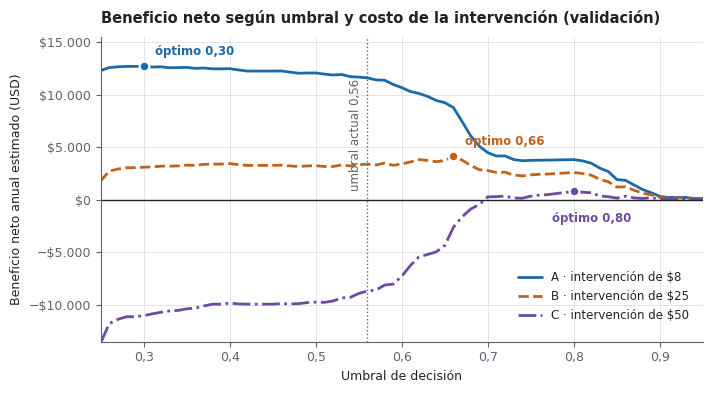

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 4.0))

desplazamiento = {"A": (8, 8), "B": (8, 8), "C": (-16, -22)}
for cod, _, costo, color, estilo in ESCENARIOS:
    serie = curvas[(curvas.escenario == cod) & (curvas.conjunto == "validación")]
    ax.plot(serie.umbral, serie.beneficio_neto, color=color, lw=2, ls=estilo,
            label=f"{cod} · intervención de ${costo:,.0f}", solid_capstyle="round")
    optimo = serie.loc[serie.beneficio_neto.idxmax()]
    ax.plot(optimo.umbral, optimo.beneficio_neto, "o", color=color, ms=7,
            mec="white", mew=1.6, zorder=5)
    ax.annotate(f"óptimo {optimo.umbral:.2f}".replace(".", ","),
                (optimo.umbral, optimo.beneficio_neto), textcoords="offset points",
                xytext=desplazamiento[cod], color=color, fontsize=8.5, fontweight="bold")

ax.axhline(0, color=TINTA, lw=1)
ax.axvline(UMBRAL_ACTUAL, color=GRIS, lw=1, ls=":")
ax.annotate(f"umbral actual {UMBRAL_ACTUAL:.2f}".replace(".", ","), (UMBRAL_ACTUAL, 0),
            textcoords="offset points", xytext=(-13, 6), color=GRIS,
            fontsize=8.5, rotation=90, va="bottom")

ax.set_xlabel("Umbral de decisión")
ax.set_ylabel("Beneficio neto anual estimado (USD)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(
    lambda v, _: ("−" if v < 0 else "") + "$" + format(int(abs(v)), ",").replace(",", ".")))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.1f}".replace(".", ",")))
ax.set_xlim(0.25, 0.95)
ax.set_ylim(-13500, 15500)
ax.set_axisbelow(True)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)
ax.legend(frameon=False, loc="lower right", fontsize=8.5, bbox_to_anchor=(0.995, 0.03))
ax.set_title("Beneficio neto según umbral y costo de la intervención (validación)",
             fontsize=10.5, fontweight="bold", loc="left", pad=10)

fig.tight_layout()
fig.savefig(ruta_figuras / "14_01_beneficio_neto_umbral.png", dpi=200)
plt.show()

## 4. Verificación crítica: ¿el óptimo económico generaliza?

Para cada escenario se elige el umbral que maximiza el beneficio **en validación** y se aplica al
conjunto de prueba. Si la ventaja frente al umbral vigente desaparece, significa que la
optimización estaba ajustando ruido y no señal.

In [8]:
comparacion = []
for cod, _, costo, _, _ in ESCENARIOS:
    val = curvas[(curvas.escenario == cod) & (curvas.conjunto == "validación")]
    test = curvas[(curvas.escenario == cod) & (curvas.conjunto == "prueba")]
    umbral_optimo = float(val.loc[val.beneficio_neto.idxmax(), "umbral"])

    for etiqueta, umbral in (("actual", UMBRAL_ACTUAL), ("óptimo en validación", umbral_optimo)):
        fila_val = val[val.umbral == round(umbral, 2)].iloc[0]
        fila_test = test[test.umbral == round(umbral, 2)].iloc[0]
        comparacion.append({
            "Escenario": f"{cod} · ${costo:,.0f}",
            "Umbral": f"{umbral:.2f} ({etiqueta})",
            "Alertas (prueba)": int(fila_test.alertas),
            "Precisión (prueba)": round(fila_test.precision, 3),
            "Recall (prueba)": round(fila_test.recall, 3),
            "Beneficio validación": round(fila_val.beneficio_neto),
            "Beneficio prueba": round(fila_test.beneficio_neto),
        })

comparacion = pd.DataFrame(comparacion)
comparacion

,Escenario,Umbral,Alertas (prueba),Precisión (prueba),Recall (prueba),Beneficio validación,Beneficio prueba
0,A · $8,0.56 (actual),499,0.234,0.765,11603,10721
1,A · $8,0.30 (óptimo en validación),572,0.229,0.856,12707,11897
2,B · $25,0.56 (actual),499,0.234,0.765,3392,2238
3,B · $25,0.66 (óptimo en validación),267,0.251,0.438,4165,1750
4,C · $50,0.56 (actual),499,0.234,0.765,-8683,-10237
5,C · $50,0.80 (óptimo en validación),76,0.434,0.216,801,350


In [9]:
# ¿El umbral óptimo en validación supera al vigente cuando se lleva a prueba?
for cod, _, costo, _, _ in ESCENARIOS:
    bloque = comparacion[comparacion["Escenario"] == f"{cod} · ${costo:,.0f}"]
    actual = bloque.iloc[0]
    optimo = bloque.iloc[1]
    delta_val = optimo["Beneficio validación"] - actual["Beneficio validación"]
    delta_test = optimo["Beneficio prueba"] - actual["Beneficio prueba"]
    sobrevive = "sí" if delta_test > 0 else "NO"
    print(f"Escenario {cod}: ventaja del óptimo en validación ${delta_val:+,.0f} · "
          f"en prueba ${delta_test:+,.0f} → ¿sobrevive?: {sobrevive}")

Escenario A: ventaja del óptimo en validación $+1,104 · en prueba $+1,176 → ¿sobrevive?: sí
Escenario B: ventaja del óptimo en validación $+773 · en prueba $-488 → ¿sobrevive?: NO
Escenario C: ventaja del óptimo en validación $+9,484 · en prueba $+10,587 → ¿sobrevive?: sí


**Lectura del resultado.** En el escenario B, el umbral 0,66 supera al 0,56 en validación, pero la
ventaja se invierte en prueba. Con 153 abandonos por conjunto, mover el umbral de 0,56 a 0,66
reduce las alertas de 483 a 271 y el beneficio queda determinado por unas pocas decenas de casos:
su variación entre conjuntos es del mismo orden que la ganancia buscada.

En el escenario C la comparación aparece como favorable solo porque la referencia es profundamente
negativa: el óptimo alcanza unos 350 dólares en prueba, una cifra indistinguible de cero frente a la
incertidumbre del propio modelo de costos. Ningún umbral vuelve viable ese escenario.

De ahí las dos conclusiones que el informe defiende:

1. La decisión que más pesa **no es el umbral sino el costo de la intervención**: la diferencia
   entre los escenarios A y C supera los veinte mil dólares anuales, mientras que la diferencia
   entre umbrales dentro de un mismo escenario es de unos pocos cientos.
2. El umbral 0,56, fijado bajo la restricción `recall ≥ 0,80`, **se mantiene**: queda cerca del
   óptimo en el escenario A, supera en prueba al óptimo calculado para el escenario B, y ningún
   umbral rescata al escenario C.

## 5. Sensibilidad de los supuestos

La precisión de equilibrio depende por completo de dos supuestos no medidos. Esta tabla muestra
cuánto margen tiene realmente el sistema.

In [10]:
costos = [8, 15, 25, 35, 50]
efectividades = [0.15, 0.30, 0.45]

sensibilidad = pd.DataFrame(
    {f"Efectividad {e:.0%}": [round(precision_de_equilibrio(c, efectividad=e), 3) for c in costos]
     for e in efectividades},
    index=[f"${c}" for c in costos],
)
sensibilidad.index.name = "Costo por alerta"
sensibilidad.to_csv(ruta_modelos / "sensibilidad_precision_equilibrio.csv")
print(f"Precisión alcanzada en prueba: {precision_test:.3f}")
print("Guardado: models/sensibilidad_precision_equilibrio.csv\n")
sensibilidad

Precisión alcanzada en prueba: 0.234
Guardado: models/sensibilidad_precision_equilibrio.csv



,Efectividad 15%,Efectividad 30%,Efectividad 45%
Costo por alerta,,,
$8,0.127,0.064,0.042
$15,0.239,0.119,0.080
$25,0.398,0.199,0.133
$35,0.557,0.278,0.186
$50,0.795,0.398,0.265


Con precisión 0,234, el sistema queda **en la frontera de la viabilidad**: bajo supuestos
favorables el margen es cómodo, y bajo supuestos conservadores desaparece. Calibrar las
probabilidades y medir la efectividad real no son refinamientos opcionales, sino la condición para
defender el sistema ante una organización.

Límites del análisis, declarados explícitamente:

- La efectividad de 0,30 y el horizonte de doce meses son supuestos, no mediciones.
- El valor en riesgo usa **ingreso** y no margen de contribución, por lo que sobreestima el
  beneficio de retener.
- Se asume un costo uniforme por cliente; en la práctica correspondería asignar acciones distintas
  según banda de riesgo y valor del cliente.

# Parte B — Comparación con aprendizaje no supervisado

## 6. Selección de k y estructura de agrupamiento

El proyecto es supervisado porque dispone de una etiqueta histórica, pero esa elección debe
sostenerse con evidencia y no solo con un argumento conceptual. Se aplica K-means sobre las
**mismas 58 características preprocesadas** del conjunto de entrenamiento.

In [11]:
MUESTRA_SILUETA = 3000
generador = np.random.RandomState(RANDOM_STATE)
indices_muestra = generador.choice(len(X_train), MUESTRA_SILUETA, replace=False)

resultados_k = []
modelos_kmeans = {}
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10).fit(X_train)
    modelos_kmeans[k] = km
    silueta = silhouette_score(X_train[indices_muestra], km.labels_[indices_muestra])
    tasas = [y_train[km.labels_ == c].mean() for c in range(k)]
    resultados_k.append({
        "k": k,
        "silueta": round(silueta, 4),
        "inercia": round(km.inertia_),
        "tasa_churn_maxima": round(max(tasas), 3),
        "factor_sobre_base": round(max(tasas) / y_train.mean(), 2),
    })

seleccion_k = pd.DataFrame(resultados_k)
print(f"Tasa base de abandono en entrenamiento: {y_train.mean():.4f}\n")
seleccion_k

Tasa base de abandono en entrenamiento: 0.1021



,k,silueta,inercia,tasa_churn_maxima,factor_sobre_base
0,2,0.0630,170727,0.107,1.04
1,3,0.0478,165848,0.107,1.05
2,4,0.0341,162218,0.125,1.22
3,5,0.0328,159405,0.127,1.24
4,6,0.0334,156889,0.254,2.49
5,7,0.0308,155074,0.255,2.50
6,8,0.0289,153023,0.256,2.51


**Primer hallazgo: el conjunto no tiene estructura de clústeres.** La silueta máxima es 0,063 con
dos grupos y desciende al aumentar k. Valores tan bajos indican grupos poco separados y con
solapamiento considerable — coherente con el análisis exploratorio, donde ninguna variable separa
las clases y las correlaciones son débiles.

Se adopta **k = 6** no por la silueta, sino porque es la primera partición que aísla un segmento
con una tasa de abandono claramente distinta de la base: el criterio de selección es la utilidad
operativa, y así se declara.

In [12]:
K_ELEGIDO = 6
kmeans = modelos_kmeans[K_ELEGIDO]
clusters_train = kmeans.labels_
clusters_val = kmeans.predict(X_val)

perfil = pd.DataFrame([
    {
        "cluster": c,
        "clientes": int((clusters_train == c).sum()),
        "pct_base": round(100 * (clusters_train == c).mean(), 1),
        "tasa_churn": round(y_train[clusters_train == c].mean(), 3),
        "factor_sobre_base": round(y_train[clusters_train == c].mean() / y_train.mean(), 2),
    }
    for c in range(K_ELEGIDO)
]).sort_values("tasa_churn", ascending=False).reset_index(drop=True)

perfil.to_csv(ruta_modelos / "perfil_clusters_kmeans.csv", index=False)
CLUSTER_RIESGO = int(perfil.iloc[0]["cluster"])
print(f"Clúster de mayor riesgo: {CLUSTER_RIESGO}")
print("Guardado: models/perfil_clusters_kmeans.csv")
perfil

Clúster de mayor riesgo: 5
Guardado: models/perfil_clusters_kmeans.csv


,cluster,clientes,pct_base,tasa_churn,factor_sobre_base
0,5,543,7.8,0.254,2.49
1,1,651,9.3,0.115,1.13
2,0,1838,26.3,0.107,1.05
3,3,1262,18.0,0.090,0.88
4,2,1128,16.1,0.083,0.82
5,4,1578,22.5,0.062,0.61


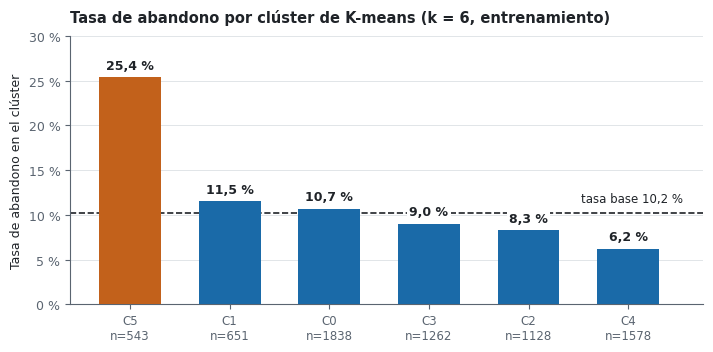

In [13]:
fig, ax = plt.subplots(figsize=(7.2, 3.6))

posiciones = np.arange(K_ELEGIDO)
valores = perfil.tasa_churn.values * 100
colores = [NARANJA] + [AZUL] * (K_ELEGIDO - 1)
ax.bar(posiciones, valores, color=colores, width=0.62, zorder=3)

tasa_base = y_train.mean() * 100
ax.axhline(tasa_base, color=TINTA, lw=1.2, ls="--", zorder=2)
ax.annotate(f"tasa base {tasa_base:.1f} %".replace(".", ","),
            (K_ELEGIDO - 0.45, tasa_base), textcoords="offset points", xytext=(0, 8),
            fontsize=8.5, color=TINTA, ha="right", zorder=6)

for x, v in zip(posiciones, valores):
    ax.annotate(f"{v:.1f} %".replace(".", ","), (x, v), textcoords="offset points",
                xytext=(0, 6), ha="center", fontsize=9, fontweight="bold", color=TINTA,
                zorder=6, bbox=dict(facecolor="white", edgecolor="none", pad=1.5))

ax.set_xticks(posiciones)
ax.set_xticklabels([f"C{int(r.cluster)}\nn={int(r.clientes)}" for r in perfil.itertuples()],
                   fontsize=8.5)
ax.set_ylabel("Tasa de abandono en el clúster")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f} %"))
ax.set_ylim(0, 30)
ax.set_xlim(-0.6, K_ELEGIDO - 0.25)
ax.set_axisbelow(True)
ax.grid(axis="x", visible=False)
for lado in ("top", "right"):
    ax.spines[lado].set_visible(False)
ax.set_title(f"Tasa de abandono por clúster de K-means (k = {K_ELEGIDO}, entrenamiento)",
             fontsize=10.5, fontweight="bold", loc="left", pad=10)

fig.tight_layout()
fig.savefig(ruta_figuras / "14_02_tasa_churn_por_cluster.png", dpi=200)
plt.show()

## 7. ¿Qué describe el clúster de mayor riesgo?

Las características ya están estandarizadas, así que la diferencia entre la media del clúster y la
media general se lee directamente como desviaciones estándar.

In [14]:
diferencia = pd.Series(
    X_train[clusters_train == CLUSTER_RIESGO].mean(axis=0) - X_train.mean(axis=0),
    index=nombres_variables,
)
principales = diferencia.reindex(diferencia.abs().sort_values(ascending=False).index).head(10)
principales.round(3).to_frame("desviaciones respecto de la media")

,desviaciones respecto de la media
numericas__payment_failures,2.393
numericas__total_revenue,-0.224
numericas__monthly_fee,-0.162
numericas__tenure_months,-0.124
numericas__escalations,-0.098
numericas__age,-0.079
numericas__last_login_days_ago,-0.075
numericas__email_open_rate,-0.073
numericas__csat_score,-0.067
numericas__avg_session_time,-0.062


El segmento se describe con precisión en una frase: **clientes con fallos de pago recurrentes**,
con menor facturación y menor antigüedad. Los fallos de pago se sitúan más de dos desviaciones
estándar por encima del promedio, mientras el resto de las variables se mantiene cerca de la media.

## 8. Comparación a igualdad de volumen de alertas

Un clúster no entrega probabilidades, así que la comparación justa es: con el **mismo número de
clientes alertados**, ¿cuántos abandonos detecta cada enfoque?

In [15]:
en_cluster = clusters_val == CLUSTER_RIESGO
n_alertas_cluster = int(en_cluster.sum())

# Enfoque supervisado con el mismo presupuesto de alertas.
orden = np.argsort(-proba_val)[:n_alertas_cluster]
seleccion_supervisada = np.zeros(len(y_val), dtype=bool)
seleccion_supervisada[orden] = True

# Enfoque supervisado con el umbral operativo vigente.
alerta_umbral = proba_val >= UMBRAL_ACTUAL


def resumen(mascara, etiqueta):
    vp = int((mascara & (y_val == 1)).sum())
    fp = int((mascara & (y_val == 0)).sum())
    return {
        "Estrategia de alerta": etiqueta,
        "Clientes alertados": vp + fp,
        "Abandonos detectados": vp,
        "Precisión": round(vp / (vp + fp), 3),
        "Recall": round(vp / y_val.sum(), 3),
    }


comparacion_paradigmas = pd.DataFrame([
    resumen(en_cluster, f"K-means: alertar todo el clúster {CLUSTER_RIESGO}"),
    resumen(seleccion_supervisada, f"Supervisado: {n_alertas_cluster} de mayor probabilidad"),
    resumen(alerta_umbral, f"Supervisado: umbral operativo {UMBRAL_ACTUAL:.2f}"),
])
comparacion_paradigmas

,Estrategia de alerta,Clientes alertados,Abandonos detectados,Precisión,Recall
0,K-means: alertar todo el clúster 5,103,25,0.243,0.163
1,Supervisado: 103 de mayor probabilidad,103,42,0.408,0.275
2,Supervisado: umbral operativo 0.56,483,123,0.255,0.804


## 9. ¿Aporta el clúster información que el modelo no tenga?

Última prueba: se reentrena XGBoost + ROS con los mismos hiperparámetros, agregando la pertenencia
al clúster como variables indicadoras. Si el desempeño no mejora, la información del agrupamiento
ya estaba contenida en las variables originales.

In [16]:
with open(ruta_modelos / "mejores_hiperparametros_xgboost.json", encoding="utf-8") as f:
    hiperparametros = json.load(f)

CLAVES_XGB = {
    "max_depth", "learning_rate", "n_estimators", "subsample",
    "colsample_bytree", "gamma", "reg_alpha", "reg_lambda", "min_child_weight",
}
parametros = {k.split("__")[-1]: v for k, v in hiperparametros.items()}
parametros = {k: v for k, v in parametros.items() if k in CLAVES_XGB}


def indicadores(etiquetas, k=K_ELEGIDO):
    matriz = np.zeros((len(etiquetas), k))
    matriz[np.arange(len(etiquetas)), etiquetas] = 1
    return matriz


def entrenar_y_evaluar(X_entrena, X_valida, etiqueta):
    X_bal, y_bal = RandomOverSampler(random_state=RANDOM_STATE).fit_resample(X_entrena, y_train)
    clf = XGBClassifier(random_state=RANDOM_STATE, eval_metric="logloss", **parametros)
    clf.fit(X_bal, y_bal)
    proba = clf.predict_proba(X_valida)[:, 1]
    prediccion = (proba >= UMBRAL_ACTUAL).astype(int)
    return {
        "Variante": etiqueta,
        "ROC-AUC": round(roc_auc_score(y_val, proba), 4),
        "PR-AUC": round(average_precision_score(y_val, proba), 4),
        "Precisión": round(precision_score(y_val, prediccion, zero_division=0), 3),
        "Recall": round(recall_score(y_val, prediccion, zero_division=0), 3),
    }


ablacion = pd.DataFrame([
    entrenar_y_evaluar(X_train, X_val, "Sin variable de clúster"),
    entrenar_y_evaluar(
        np.hstack([X_train, indicadores(clusters_train)]),
        np.hstack([X_val, indicadores(clusters_val)]),
        f"Con clúster (one-hot, k = {K_ELEGIDO})",
    ),
])
ablacion

,Variante,ROC-AUC,PR-AUC,Precisión,Recall
0,Sin variable de clúster,0.8282,0.3406,0.254,0.797
1,"Con clúster (one-hot, k = 6)",0.8265,0.3380,0.256,0.810


## 10. Conclusión de la comparación de paradigmas

**Se mantiene el enfoque supervisado como solución principal.** Aprovecha la etiqueta histórica,
ordena a los clientes por probabilidad y permite ajustar el umbral según el objetivo de negocio:
tres capacidades que el agrupamiento no ofrece. A igualdad de volumen de alertas detecta cerca del
doble de abandonos, y agregar la pertenencia al clúster como variable no mejora el desempeño.

**El aporte del análisis no supervisado es de otra naturaleza, y sí es real.** Entrega un segmento
accionable y descriptible en una frase —clientes con fallos de pago recurrentes— sobre el que
corresponde una intervención distinta de una oferta de retención, como la recuperación del medio de
pago. Ese segmento puede gestionarse con una regla estable, sin depender del modelo ni de su
reentrenamiento, y conecta directamente con el análisis de costos de la Parte A: es precisamente el
tipo de acción barata para la que el sistema sí genera valor.